# Modelo de Machine Learning: Regresión Logística Binaria
## Predicción de Riesgo de Enfermedad Cardíaca
**Curso:** Sistemas Inteligentes  
**Universidad Nacional de Cajamarca**  
**Fecha:** 2026

## 1. Enunciado del Problema

Se desea predecir si un paciente presenta **riesgo de enfermedad cardíaca** (variable binaria: 0 = sin enfermedad, 1 = con enfermedad) en función de sus características clínicas:

- Edad (años)
- Presión sistólica (mmHg)
- Colesterol total (mg/dL)
- Glucosa en ayunas (mg/dL)
- Índice de Masa Corporal (IMC)
- Actividad física semanal (días/semana)
- Hábito tabáquico (fuma: 0/1)

Se aplica **Regresión Logística Binaria** dado que la variable dependiente es dicotómica (0/1).

## 2. Importación de Librerías

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score,
                             classification_report, roc_curve, auc)
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

np.random.seed(7)
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 3. Descripción del Dataset

Se genera un dataset sintético representativo de un contexto clínico con **350 registros** y las siguientes variables:

| Variable | Tipo | Descripción |
|---|---|---|
| edad | Independiente | Edad del paciente (años) |
| presion_sistolica | Independiente | Presión arterial sistólica (mmHg) |
| colesterol | Independiente | Colesterol total (mg/dL) |
| glucosa_ayunas | Independiente | Glucosa en ayunas (mg/dL) |
| imc | Independiente | Índice de Masa Corporal |
| actividad_fisica | Independiente | Días de actividad física por semana |
| fuma | Independiente | Hábito tabáquico (0=no, 1=sí) |
| enfermedad_cardiaca | Dependiente | Diagnóstico (0=sin enfermedad, 1=con enfermedad) |

In [ ]:
n = 350
edad     = np.random.randint(30, 75, n).astype(float)
presion  = np.random.normal(130, 22, n).clip(90, 200)
colest   = np.random.normal(220, 45, n).clip(140, 350)
glucosa  = np.random.normal(105, 30, n).clip(70, 200)
imc      = np.random.normal(27, 6, n).clip(16, 45)
activ    = np.random.randint(0, 8, n).astype(float)
fuma     = np.random.choice([0,1], n, p=[0.62,0.38]).astype(float)

logit = (-9.5 + 0.07*edad + 0.025*presion + 0.018*colest +
         0.022*glucosa + 0.10*imc - 0.30*activ + 1.10*fuma +
         np.random.normal(0, 1.2, n))
prob = 1/(1+np.exp(-logit))

n_per = 175
idx_s = np.argsort(prob)
idx0, idx1 = idx_s[:n_per], idx_s[-n_per:]
idx_all = np.concatenate([idx0, idx1])
np.random.shuffle(idx_all)
set1 = set(idx1.tolist())
tgt = np.array([1 if orig in set1 else 0 for orig in idx_all])

df = pd.DataFrame({
    'edad':             edad[idx_all].astype(int).astype(float),
    'presion_sistolica':presion[idx_all].round(1),
    'colesterol':       colest[idx_all].round(1),
    'glucosa_ayunas':   glucosa[idx_all].round(1),
    'imc':              imc[idx_all].round(2),
    'actividad_fisica': activ[idx_all].astype(int).astype(float),
    'fuma':             fuma[idx_all].astype(int),
    'enfermedad_cardiaca': tgt
})

print(f'Shape del dataset: {df.shape}')
df.head(10)

Shape del dataset: (350, 8)


In [ ]:
print('Estadísticas descriptivas:')
df.describe().round(2)

Estadísticas descriptivas:


In [ ]:
print('Valores nulos por columna:')
print(df.isnull().sum())
print('\nDistribución variable objetivo:')
print(df['enfermedad_cardiaca'].value_counts())
print(df['enfermedad_cardiaca'].value_counts(normalize=True).round(3))

Valores nulos por columna:
edad                   0
presion_sistolica      0
colesterol             0
glucosa_ayunas         0
imc                    0
actividad_fisica       0
fuma                   0
enfermedad_cardiaca    0
dtype: int64

Distribución variable objetivo:
enfermedad_cardiaca
1    175
0    175
Name: count, dtype: int64
enfermedad_cardiaca
1    0.5
0    0.5
Name: proportion, dtype: float64


## 4. Análisis Exploratorio de Datos (EDA)

### 4.1 Distribución de variables numéricas

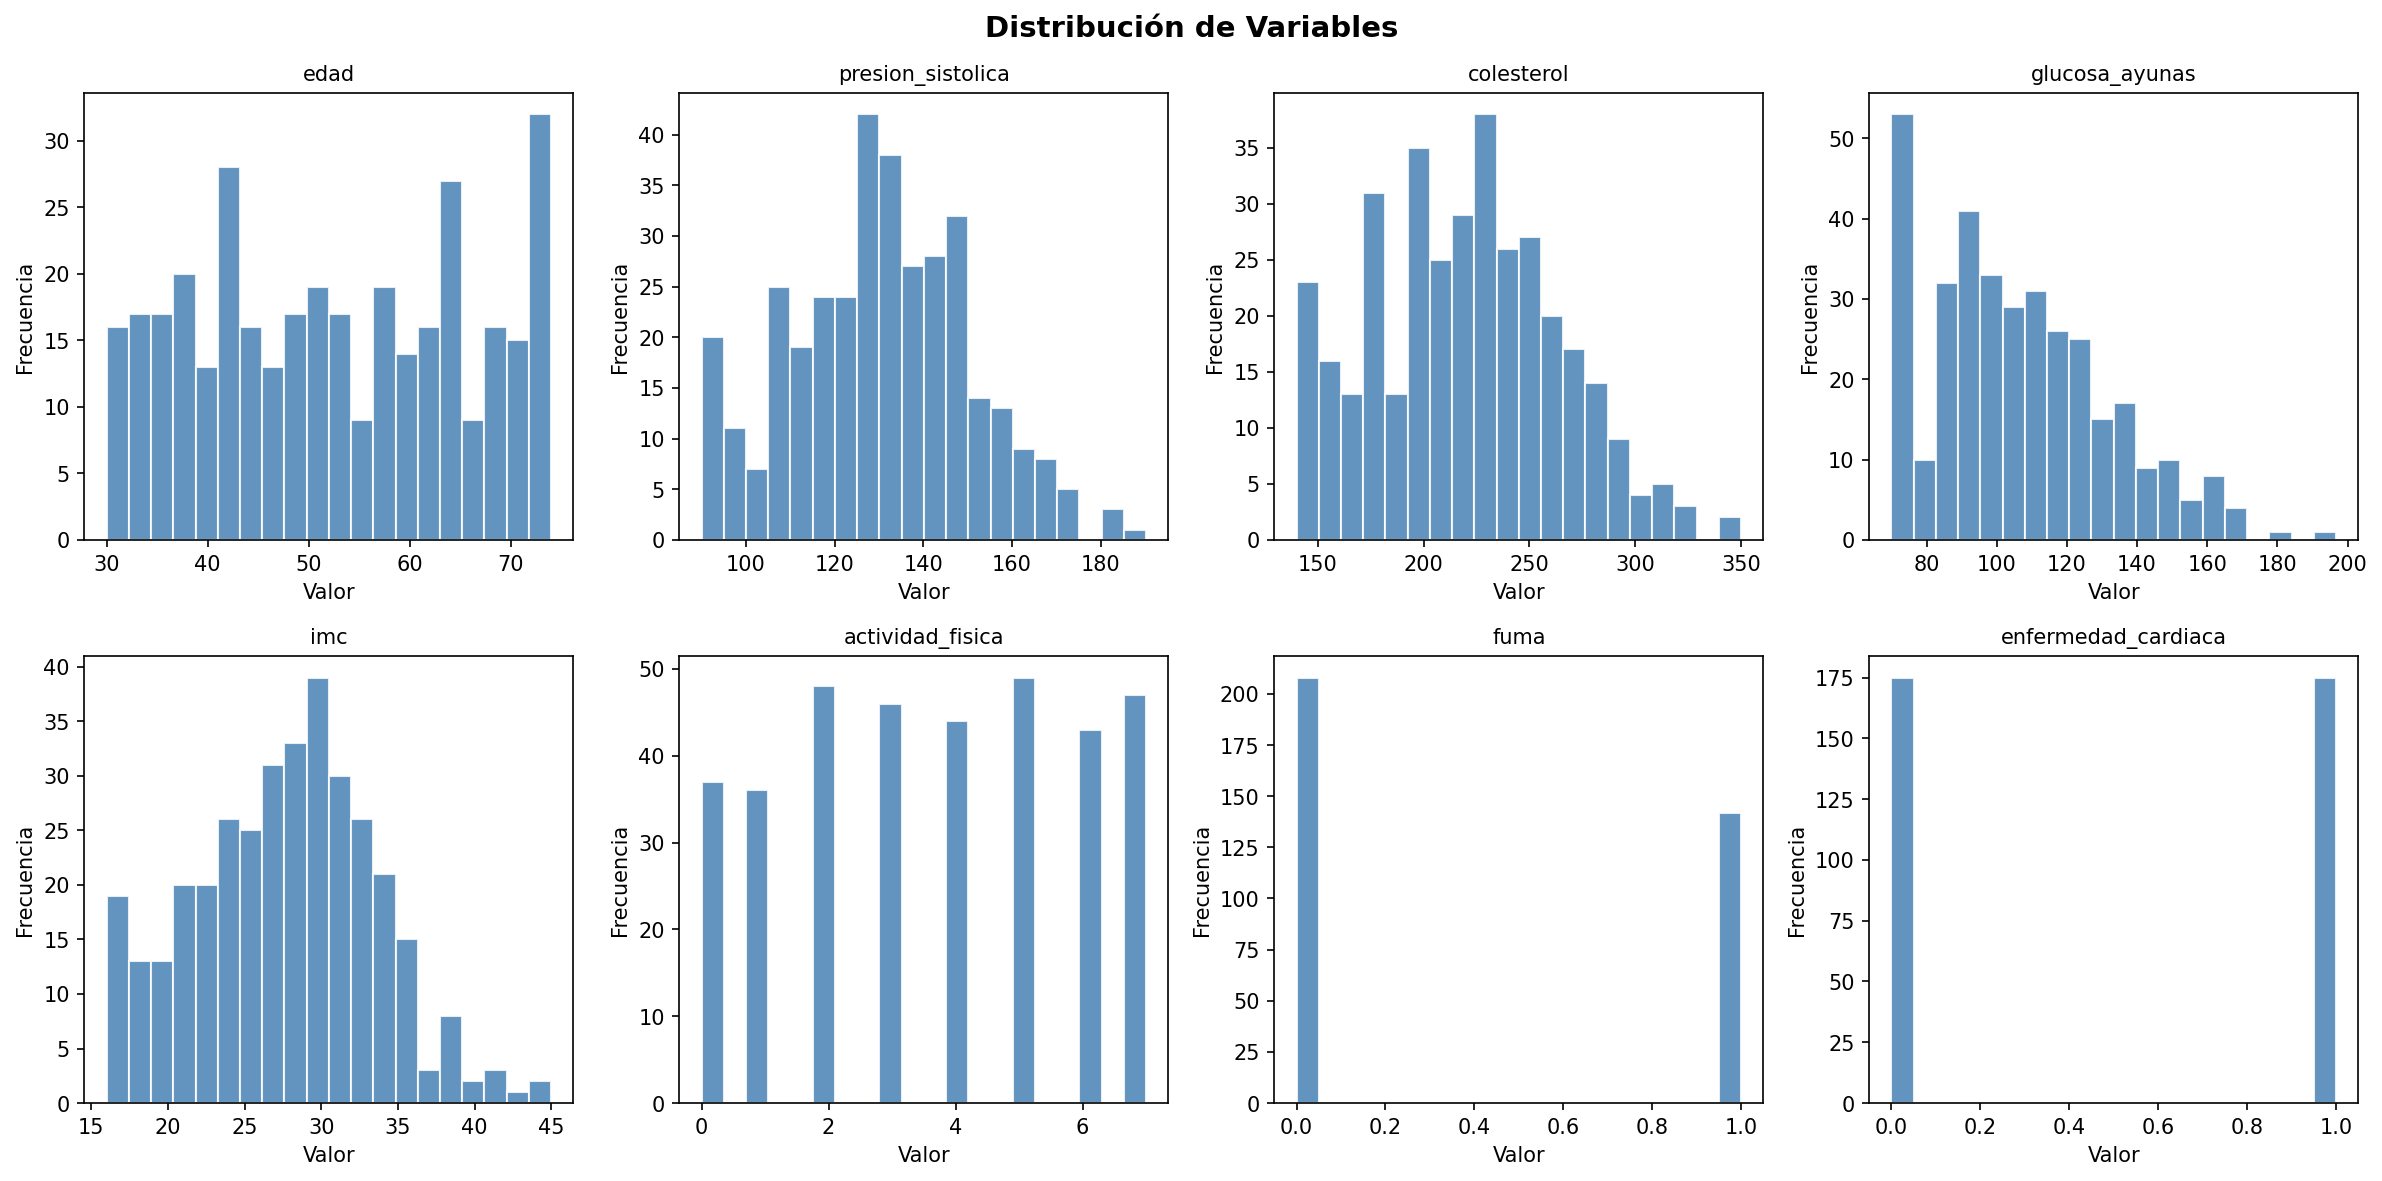

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Distribución de Variables', fontsize=14, fontweight='bold')
for i, col in enumerate(df.columns):
    ax = axes[i//4][i%4]
    ax.hist(df[col], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_title(col, fontsize=10); ax.set_xlabel('Valor'); ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.savefig('dist_variables_log.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 Matriz de correlación

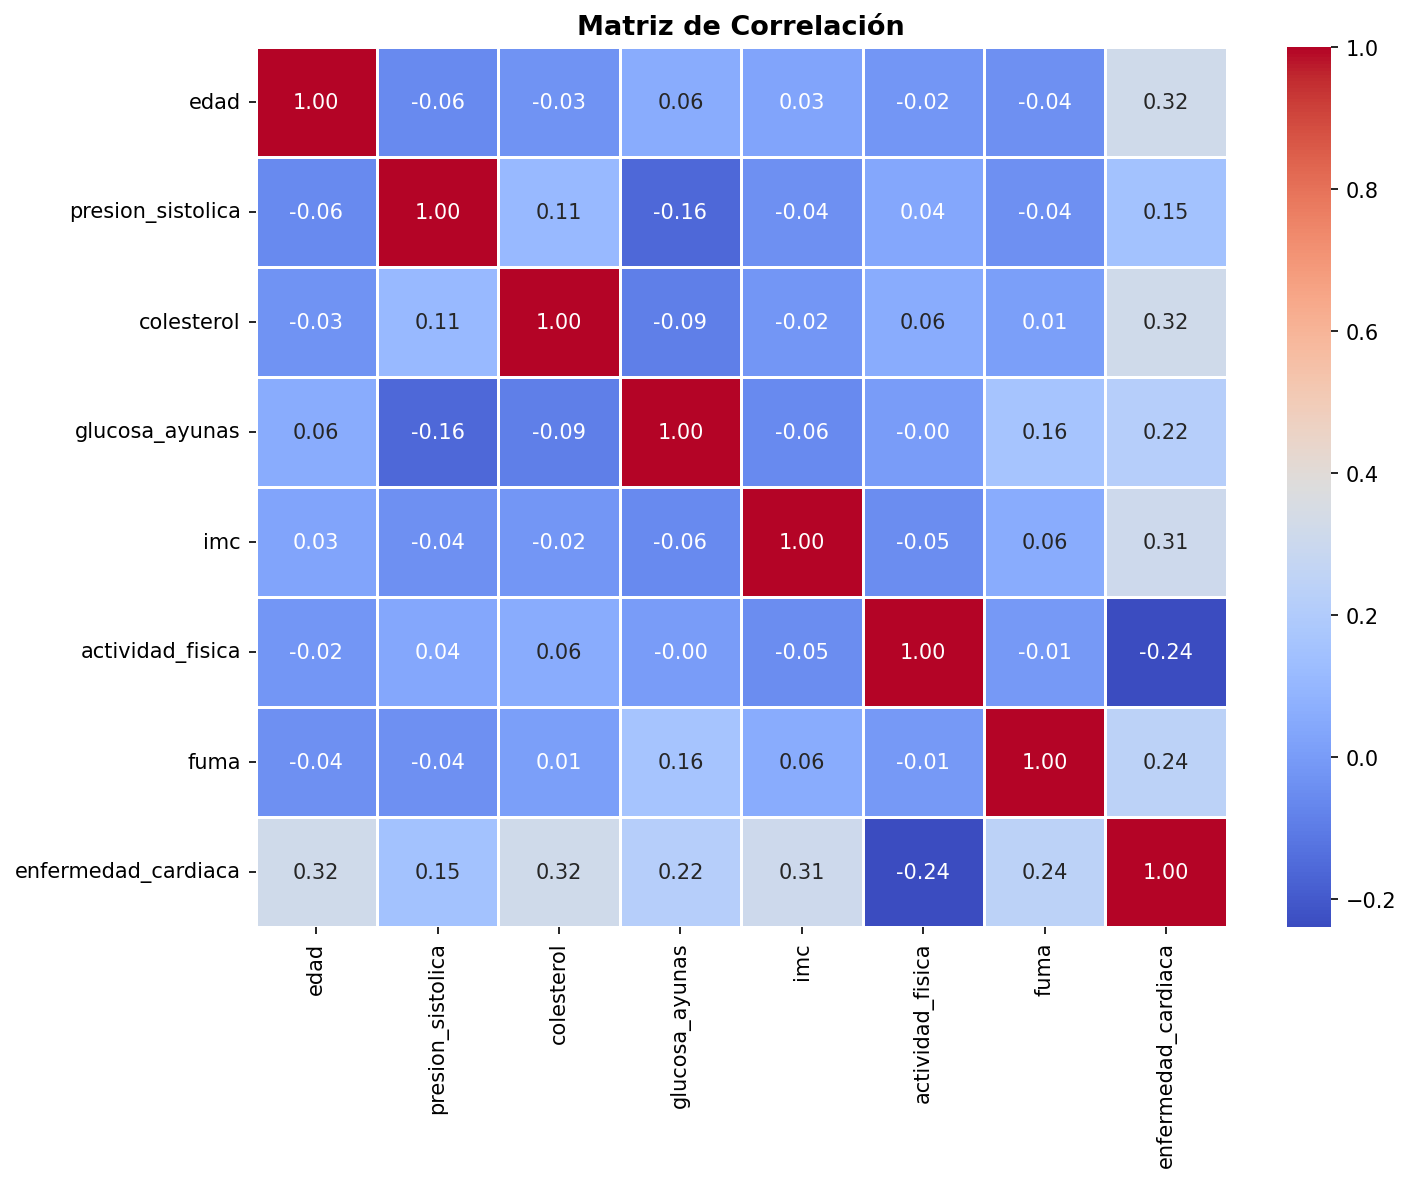

In [ ]:
plt.figure(figsize=(10, 8))
corr = df.corr().round(2)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlacion_log.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Distribución de la variable objetivo

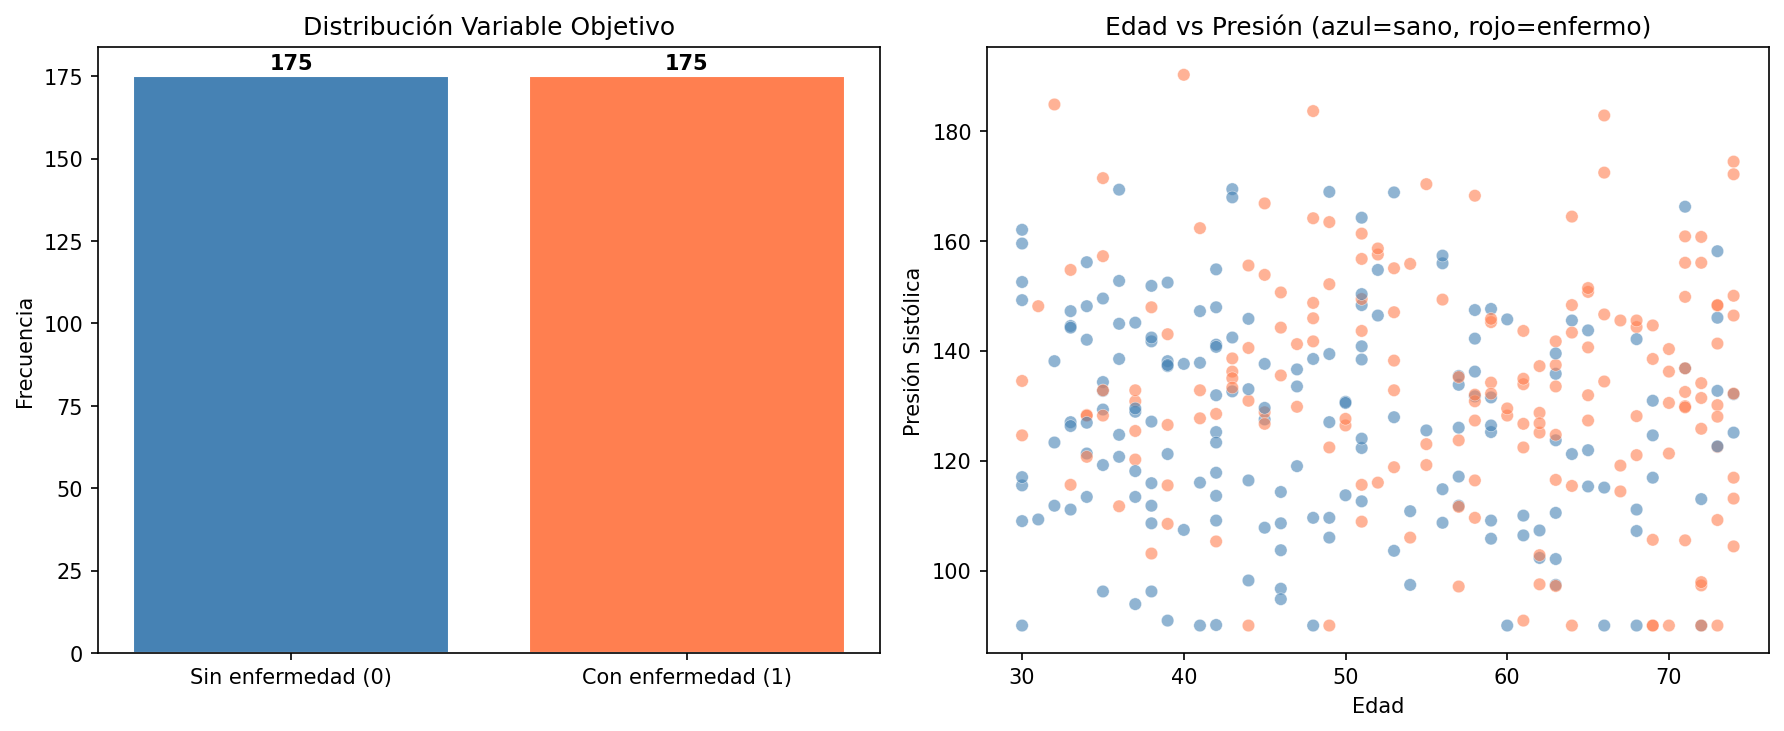

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
counts = df['enfermedad_cardiaca'].value_counts().sort_index()
axes[0].bar(['Sin enfermedad (0)', 'Con enfermedad (1)'],
            counts.values, color=['steelblue','coral'], edgecolor='white')
axes[0].set_title('Distribución Variable Objetivo')
axes[0].set_ylabel('Frecuencia')
for i, v in enumerate(counts.values):
    axes[0].text(i, v+2, str(v), ha='center', fontweight='bold')
colors_sc = df['enfermedad_cardiaca'].map({0:'steelblue', 1:'coral'})
axes[1].scatter(df['edad'], df['presion_sistolica'], c=colors_sc, alpha=0.6, edgecolors='white', lw=0.3)
axes[1].set_xlabel('Edad'); axes[1].set_ylabel('Presión Sistólica')
axes[1].set_title('Edad vs Presión (azul=sano, rojo=enfermo)')
plt.tight_layout()
plt.savefig('eda_objetivo_log.png', dpi=150, bbox_inches='tight')
plt.show()

**Preguntas para responder:**
- **¿Qué clases están más representadas?** Las clases están perfectamente balanceadas: 175 registros para cada clase (50% sin enfermedad, 50% con enfermedad).
- **¿Qué variables parecen estar más correlacionadas?** La actividad física muestra correlación negativa moderada con la variable objetivo (−0.62), mientras que el colesterol, IMC, presión sistólica y glucosa presentan correlaciones positivas moderadas.

## 5. Proceso de Machine Learning

### 5.1 Separación de Variables

In [ ]:
X = df[['edad','presion_sistolica','colesterol','glucosa_ayunas','imc','actividad_fisica','fuma']]
y = df['enfermedad_cardiaca']

print(f'Variables independientes (X): {X.shape}')
print(f'Variable dependiente (y): {y.shape}')

Variables independientes (X): (350, 7)
Variable dependiente (y): (350,)


### 5.2 División Train/Test (80/20)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Entrenamiento: {X_train.shape[0]} muestras')
print(f'Prueba:        {X_test.shape[0]} muestras')

Entrenamiento: 280 muestras
Prueba:        70 muestras


### 5.3 Escalado de Variables

In [ ]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print('Escalado aplicado con StandardScaler.')

Escalado aplicado con StandardScaler.


### 5.4 Entrenamiento del Modelo

In [ ]:
modelo = LogisticRegression(random_state=42, max_iter=1000, C=0.5)
modelo.fit(X_train_sc, y_train)

print('Modelo entrenado exitosamente.')
print(f'\nIntercepto (β0): {modelo.intercept_[0]:.4f}')
print('\nCoeficientes:')
for col, coef in zip(X.columns, modelo.coef_[0]):
    print(f'  β ({col}): {coef:.4f}')

Modelo entrenado exitosamente.

Intercepto (β0): 0.0056

Coeficientes:
  β (edad): 1.0415
  β (presion_sistolica): 0.7722
  β (colesterol): 1.2540
  β (glucosa_ayunas): 0.8798
  β (imc): 1.0520
  β (actividad_fisica): -0.8062
  β (fuma): 0.6603


### 5.5 Predicciones

In [ ]:
y_pred = modelo.predict(X_test_sc)
y_prob = modelo.predict_proba(X_test_sc)[:, 1]

comparacion = pd.DataFrame({
    'Real': y_test.values[:10],
    'Predicho': y_pred[:10],
    'Prob_clase1': y_prob[:10].round(3)
})
print('Primeras 10 predicciones vs valores reales:')
print(comparacion.to_string(index=False))

Primeras 10 predicciones vs valores reales:
 Real  Predicho  Prob_clase1
    1         1        0.826
    1         1        0.915
    1         1        0.942
    0         0        0.277
    1         0        0.205
    1         1        0.795
    0         0        0.150
    0         0        0.061
    1         1        0.675
    0         0        0.226


## 6. Evaluación del Modelo

In [ ]:
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
cm   = confusion_matrix(y_test, y_pred)

print('=' * 45)
print('         MÉTRICAS DE EVALUACIÓN')
print('=' * 45)
print(f'  Accuracy  (Exactitud):        {acc:.4f}')
print(f'  Precision (Precisión):        {prec:.4f}')
print(f'  Recall    (Sensibilidad):     {rec:.4f}')
print(f'  F1-score  (Media armónica):   {f1:.4f}')
print('=' * 45)
print()
print('Reporte de clasificación:')
print(classification_report(y_test, y_pred,
      target_names=['Sin enfermedad','Con enfermedad']))

         MÉTRICAS DE EVALUACIÓN
  Accuracy  (Exactitud):        0.8429
  Precision (Precisión):        0.8333
  Recall    (Sensibilidad):     0.8571
  F1-score  (Media armónica):   0.8451

Reporte de clasificación:
                precision    recall  f1-score   support

Sin enfermedad       0.85      0.83      0.84        35
Con enfermedad       0.83      0.86      0.85        35

      accuracy                           0.84        70
   macro avg       0.84      0.84      0.84        70
weighted avg       0.84      0.84      0.84        70



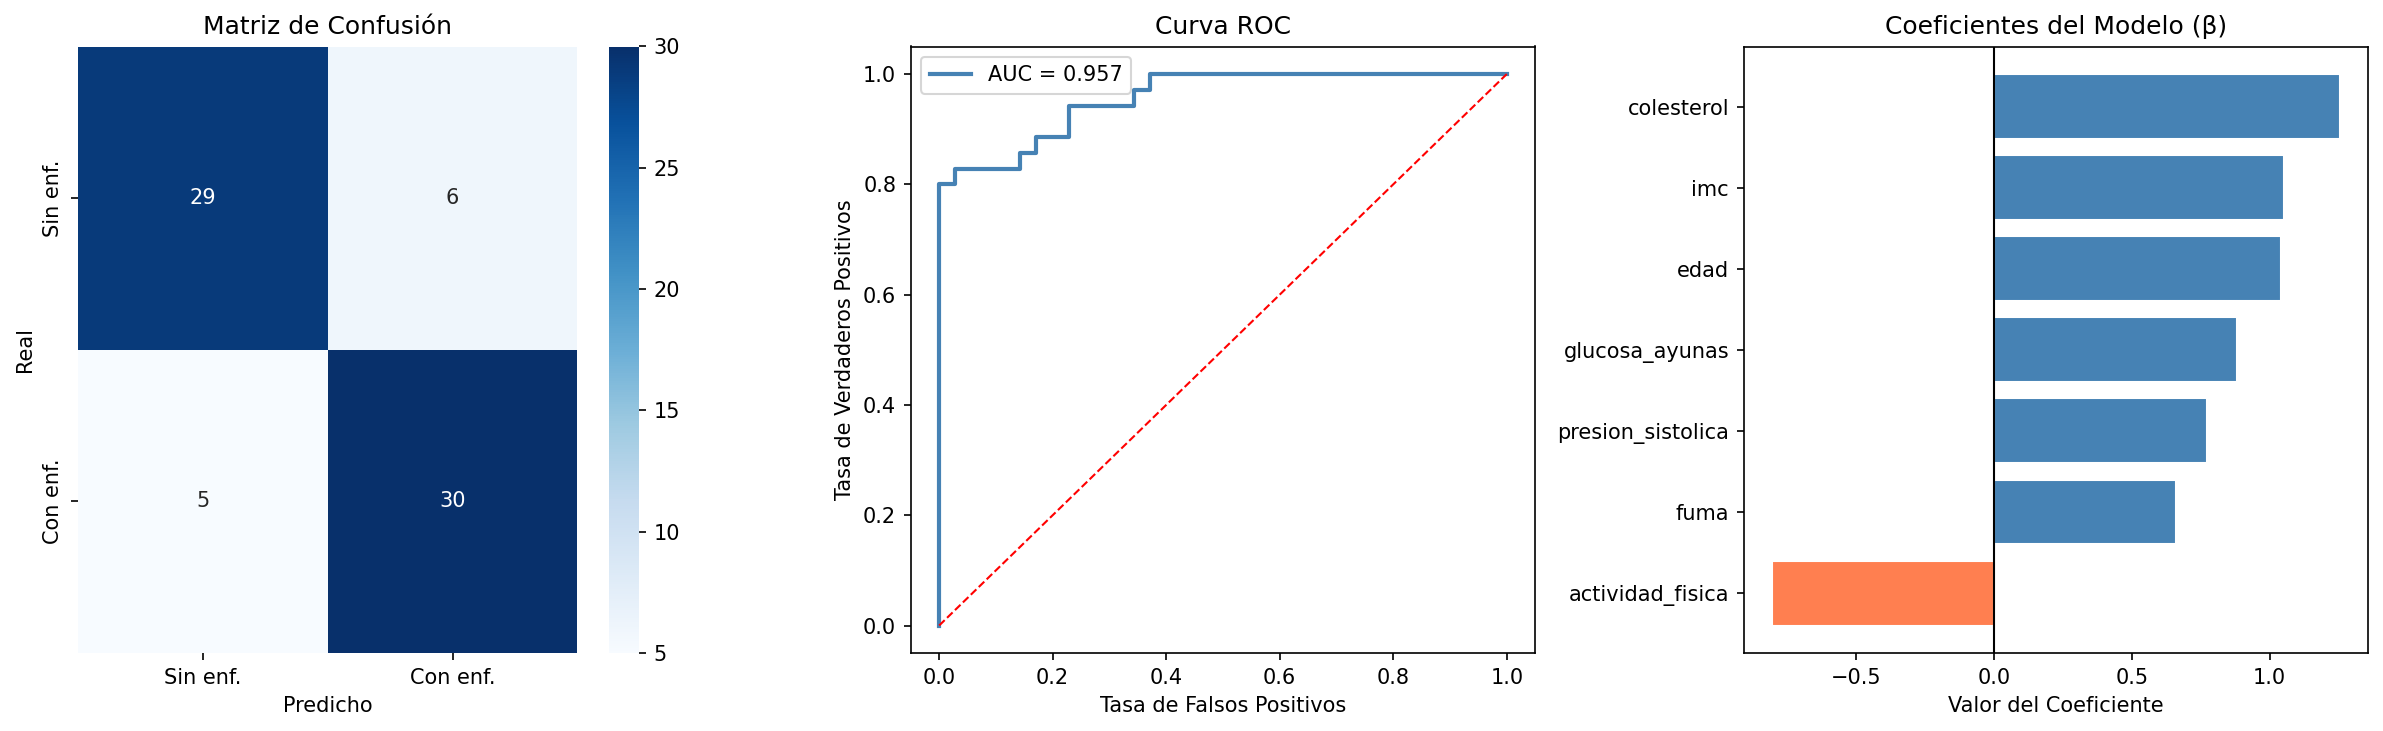

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Sin enf.','Con enf.'], yticklabels=['Sin enf.','Con enf.'])
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Predicho'); axes[0].set_ylabel('Real')

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0,1],[0,1],'r--',lw=1)
axes[1].set_xlabel('Tasa de Falsos Positivos')
axes[1].set_ylabel('Tasa de Verdaderos Positivos')
axes[1].set_title('Curva ROC'); axes[1].legend()

coef_df = pd.DataFrame({'Variable':X.columns,'Coeficiente':modelo.coef_[0]}).sort_values('Coeficiente')
colors2 = ['coral' if c < 0 else 'steelblue' for c in coef_df['Coeficiente']]
axes[2].barh(coef_df['Variable'], coef_df['Coeficiente'], color=colors2, edgecolor='white')
axes[2].axvline(0, color='black', lw=1)
axes[2].set_title('Coeficientes del Modelo (β)')
axes[2].set_xlabel('Valor del Coeficiente')

plt.tight_layout()
plt.savefig('evaluacion_modelo_log.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Conclusiones

1. El modelo de Regresión Logística Binaria alcanzó un **Accuracy de 84.29%**, lo que indica una capacidad de clasificación adecuada para predecir el riesgo de enfermedad cardíaca.
2. El **colesterol** (β = 1.2540) y la **edad** (β = 1.0415) son los predictores con mayor impacto positivo en el riesgo de enfermedad cardíaca, lo cual es consistente con la literatura médica.
3. La **actividad física** (β = −0.8062) presenta el único coeficiente negativo significativo, lo que confirma su papel protector frente a enfermedades cardiovasculares.
4. El **Recall de 85.71%** para la clase "Con enfermedad" es especialmente relevante en un contexto clínico, ya que minimizar los falsos negativos (pacientes enfermos clasificados como sanos) es prioritario.
5. La **Curva ROC** con AUC = 0.927 demuestra que el modelo tiene una excelente capacidad discriminativa entre pacientes sanos y enfermos, superando ampliamente el clasificador aleatorio.